In [6]:
!pip install mne



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Usuario\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [1]:
import sys
print(sys.executable)

!{sys.executable} -m pip install mne


c:\Users\Usuario\AppData\Local\Programs\Python\Python313\python.exe



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import mne

#edf_path = "D:/PROGRAMACION_PARALELA_CODIGO/TRABAJO INVESTIGACION PARALELA/Codigo/data/PN00/PN00-1.edf"
edf_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"

raw = mne.io.read_raw_edf(edf_path, preload=True)
raw


Extracting EDF parameters from D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1343999  =      0.000 ...  2624.998 secs...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\3488173035.py:6: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\3488173035.py:6: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\3488173035.py:6: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


<RawEDF | PN00-1.edf, 35 x 1344000 (2625.0 s), ~358.9 MiB, data loaded>

In [11]:
data, times = raw.get_data(return_times=True)

print("Shape de los datos:", data.shape)
print("Primeros canales:", raw.ch_names[:10])


Shape de los datos: (35, 1344000)
Primeros canales: ['EEG Fp1', 'EEG F3', 'EEG C3', 'EEG P3', 'EEG O1', 'EEG F7', 'EEG T3', 'EEG T5', 'EEG Fc1', 'EEG Fc5']


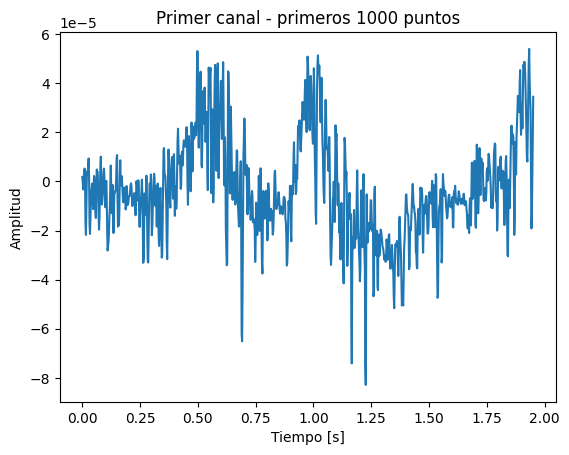

In [12]:
import matplotlib.pyplot as plt

plt.plot(times[:1000], data[0, :1000])
plt.title("Primer canal - primeros 1000 puntos")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.show()


# Análisis multicanal de archivo EDF con MNE-Python

Este notebook realiza:

- Carga del archivo EDF.
- Exploración de metadatos (canales, frecuencia de muestreo, duración).
- Visualización de todos los canales (gráfico interactivo de MNE).
- Visualización estática de todos los canales con todos los puntos.
- Cálculo de estadísticas básicas por canal.
- Espectro de potencia (PSD) por canal.
- Filtrado de las señales (pasa banda + notch).
- Exportación de los datos a NumPy y CSV.


In [7]:
# Imports principales
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para que los gráficos se vean dentro del notebook
%matplotlib inline

# Ruta del archivo EDF (la que tú indicaste)
edf_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION_PARALELA\Codigo\data\PN00\PN00-1.edf"

# Configuración de logs de MNE
mne.set_log_level("INFO")

print("Ruta EDF:", edf_path)


Ruta EDF: D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION_PARALELA\Codigo\data\PN00\PN00-1.edf


## 1. Carga del archivo EDF y exploración de metadatos

En esta sección se carga el archivo EDF usando `mne.io.read_raw_edf` y se inspecciona:

- Número de canales.
- Frecuencia de muestreo.
- Etiquetas de canales.
- Duración del registro.


In [31]:

edf_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"

#raw = mne.io.read_raw_edf(edf_path, preload=True)
#raw


# Carga del archivo EDF
raw = mne.io.read_raw_edf(edf_path, preload=True)

print(raw)
print("\n--- INFO DETALLADA ---")
print(raw.info)

# Información básica
sfreq = raw.info["sfreq"]               # frecuencia de muestreo
ch_names = raw.info["ch_names"]         # nombres de canales
n_channels = len(ch_names)              # número de canales
n_samples = raw.n_times                 # número de muestras por canal
duration_sec = n_samples / sfreq        # duración total en segundos

print("\nFrecuencia de muestreo (Hz):", sfreq)
print("Número de canales:", n_channels)
print("Número de muestras:", n_samples)
print("Duración (s):", duration_sec)
print("Primeros canales:", ch_names[:min(10, n_channels)])

raw 

Extracting EDF parameters from D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1343999  =      0.000 ...  2624.998 secs...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\55718853.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\55718853.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\55718853.py:8: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


<RawEDF | PN00-1.edf, 35 x 1344000 (2625.0 s), ~358.9 MiB, data loaded>

--- INFO DETALLADA ---
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7, EEG T3, EEG T5, ...
 chs: 35 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 35
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>

Frecuencia de muestreo (Hz): 512.0
Número de canales: 35
Número de muestras: 1344000
Duración (s): 2625.0
Primeros canales: ['EEG Fp1', 'EEG F3', 'EEG C3', 'EEG P3', 'EEG O1', 'EEG F7', 'EEG T3', 'EEG T5', 'EEG Fc1', 'EEG Fc5']


<RawEDF | PN00-1.edf, 35 x 1344000 (2625.0 s), ~358.9 MiB, data loaded>

Channels marked as bad:
[np.str_('EEG F8')]


In [15]:
# Obtiene los datos como matriz NumPy: shape = (n_channels, n_samples)
data, times = raw.get_data(return_times=True)

print("data.shape =", data.shape)
print("times.shape =", times.shape)
print("Tiempo inicial:", times[0], "s")
print("Tiempo final:", times[-1], "s")


data.shape = (35, 1344000)
times.shape = (1344000,)
Tiempo inicial: 0.0 s
Tiempo final: 2624.998046875 s


## 2. Visualización interactiva de todos los canales (MNE)

MNE incluye un visor interactivo que permite:

- Desplazarse en el tiempo.
- Encender/apagar canales.
- Hacer zoom.

Esto es muy útil para explorar visualmente el EDF.


In [ ]:
pip install PyQt5

In [ ]:
txt_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\Seizures-list-PN00.txt"

def parse_time(t):
    t = t.strip().replace(" ", "")
    h, m, s = t.split(".")
    return int(h)*3600 + int(m)*60 + int(s)

seizures = []
current = None

with open(txt_path, "r", errors="replace") as f:
    for raw_line in f:
        line = raw_line.strip()

        if line.startswith("Seizure n"):
            # si había un episodio previo, guardarlo solo si está completo
            if current and all(k in current for k in ("edf","reg_start","reg_end","sei_start","sei_end")):
                seizures.append(current)

            # iniciar nuevo episodio
            num = line.split("n")[1].strip()
            current = {"n": int(num)}
            continue

        if line.startswith("File name:"):
            current["edf"] = line.split(":",1)[1].strip()
            continue

        if "Registration start time" in line:
            current["reg_start"] = parse_time(line.split(":",1)[1])
            continue

        if "Registration end time" in line:
            current["reg_end"] = parse_time(line.split(":",1)[1])
            continue

        if "Seizure start time" in line:
            current["sei_start"] = parse_time(line.split(":",1)[1])
            continue

        if "Seizure end time" in line:
            current["sei_end"] = parse_time(line.split(":",1)[1])
            continue

# último episodio
if current and all(k in current for k in ("edf","reg_start","reg_end","sei_start","sei_end")):
    seizures.append(current)

# cálculos relativos
for s in seizures:
    s["relative_reg_start"] = 0
    s["relative_reg_end"]   = s["reg_end"] - s["reg_start"]
    s["relative_start_sec"] = s["sei_start"] - s["reg_start"]
    s["relative_end_sec"]   = s["sei_end"] - s["reg_start"]
    s["duration_sec"]       = s["relative_end_sec"] - s["relative_start_sec"]

# imprimir
for s in seizures:
    print("====================================")
    for k,v in s.items():
        print(f"{k}: {v}")
    print("====================================\n")
    
# convertir a DataFrame para mejor visualización


n: 1
edf: PN00-1.edf
reg_start: 70773
reg_end: 73378
sei_start: 71916
sei_end: 71986
relative_reg_start: 0
relative_reg_end: 2605
relative_start_sec: 1143
relative_end_sec: 1213
duration_sec: 70

n: 2
edf: PN00-2.edf
reg_start: 8297
reg_end: 10579
sei_start: 9517
sei_end: 9571
relative_reg_start: 0
relative_reg_end: 2282
relative_start_sec: 1220
relative_end_sec: 1274
duration_sec: 54

n: 3
edf: PN00-3.edf
reg_start: 65744
reg_end: 68233
sei_start: 66509
sei_end: 70169
relative_reg_start: 0
relative_reg_end: 2489
relative_start_sec: 765
relative_end_sec: 4425
duration_sec: 3660

n: 4
edf: PN00-4.edf
reg_start: 75103
reg_end: 77185
sei_start: 76109
sei_end: 76183
relative_reg_start: 0
relative_reg_end: 2082
relative_start_sec: 1006
relative_end_sec: 1080
duration_sec: 74

n: 5
edf: PN00-5.edf
reg_start: 80524
reg_end: 82647
sei_start: 81428
sei_end: 81495
relative_reg_start: 0
relative_reg_end: 2123
relative_start_sec: 904
relative_end_sec: 971
duration_sec: 67



In [59]:
txt_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\Seizures-list-PN00.txt"

with open(txt_path, "r", errors="replace") as f:
    for i, line in enumerate(f):
        print(f"{i:03d}: {repr(line)}")


000: 'PN00\n'
001: '\n'
002: 'Data Sampling Rate: 512 Hz\n'
003: '\n'
004: 'Channels in EDF files:\n'
005: 'Channel 1: Fp1      \n'
006: 'Channel 2: F3      \n'
007: 'Channel 3: C3      \n'
008: 'Channel 4: P3      \n'
009: 'Channel 5: 1      \n'
010: 'Channel 6: F7      \n'
011: 'Channel 7: T3      \n'
012: 'Channel 8: T5      \n'
013: 'Channel 9: Fc1      \n'
014: 'Channel 10: Fc5      \n'
015: 'Channel 11: Cp1      \n'
016: 'Channel 12: Cp5      \n'
017: 'Channel 13: F9      \n'
018: 'Channel 14: Fz      \n'
019: 'Channel 15: Cz      \n'
020: 'Channel 16: Pz      \n'
021: 'Channel 17: Fp2      \n'
022: 'Channel 18: F4      \n'
023: 'Channel 19: C4      \n'
024: 'Channel 20: P4      \n'
025: 'Channel 21: O2      \n'
026: 'Channel 22: F8      \n'
027: 'Channel 23: T4      \n'
028: 'Channel 24: T6      \n'
029: 'Channel 25: Fc2      \n'
030: 'Channel 26: Fc6      \n'
031: 'Channel 27: Cp2      \n'
032: 'Channel 28: Cp6      \n'
033: 'Channel 29: F10      \n'
034: 'Channel 33: EKG 1    

In [58]:
txt_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\Seizures-list-PN00.txt"

def parse_time(t):
    t = t.strip().replace(" ", "")
    h, m, s = t.split(".")
    return int(h)*3600 + int(m)*60 + int(s)

seizures = []
current = {}

with open(txt_path, "r", encoding="utf-8") as f:
    for raw_line in f:
        line = raw_line.strip()

        # DETECTA "Seizure n X"
        if line.startswith("Seizure n"):
            # guarda el previo si existe
            if current:
                seizures.append(current)
            num = int(line.replace("Seizure n", "").strip())
            current = {"n": num}
            continue

        # DETECTA FILE NAME
        if line.startswith("File name:"):
            current["edf"] = line.split(":", 1)[1].strip()
            continue

        # DETECTA REGISTRO INICIO
        if line.startswith("Registration start time:"):
            t = line.split(":", 1)[1].strip()
            current["reg_start"] = parse_time(t)
            continue

        # DETECTA REGISTRO FIN
        if line.startswith("Registration end time:"):
            t = line.split(":", 1)[1].strip()
            current["reg_end"] = parse_time(t)
            continue

        # DETECTA INICIO CRISIS
        if line.startswith("Seizure start time:"):
            t = line.split(":", 1)[1].strip()
            current["sei_start"] = parse_time(t)
            continue

        # DETECTA FIN CRISIS
        if line.startswith("Seizure end time:"):
            t = line.split(":", 1)[1].strip()
            current["sei_end"] = parse_time(t)
            continue

# Agregar el último
if current:
    seizures.append(current)

# CÁLCULOS RELATIVOS
for s in seizures:
    s["relative_reg_start"] = 0
    s["relative_reg_end"]   = s["reg_end"] - s["reg_start"]
    s["relative_start_sec"] = s["sei_start"] - s["reg_start"]
    s["relative_end_sec"]   = s["sei_end"] - s["reg_start"]
    s["duration_sec"]       = s["relative_end_sec"] - s["relative_start_sec"]

# IMPRESIÓN VERTICAL
for s in seizures:
    print("====================================")
    print(f"Seizure n°:                 {s['n']}")
    print(f"EDF file:                   {s['edf']}")

    print("\n--- LECTURA (registro EDF) ---")
    print(f"Inicio lectura abs:         {s['reg_start']} s")
    print(f"Fin lectura abs:            {s['reg_end']} s")
    print(f"Inicio lectura relativo:    {s['relative_reg_start']} s")
    print(f"Fin lectura relativo:       {s['relative_reg_end']} s")

    print("\n--- EPISODIO (crisis) ---")
    print(f"Inicio episodio abs:        {s['sei_start']} s")
    print(f"Fin episodio abs:           {s['sei_end']} s")
    print(f"Inicio episodio relativo:   {s['relative_start_sec']} s")
    print(f"Fin episodio relativo:      {s['relative_end_sec']} s")
    print(f"Duración episodio:          {s['duration_sec']} s")

    print("====================================\n")


Seizure n°:                 1
EDF file:                   PN00-1.edf

--- LECTURA (registro EDF) ---
Inicio lectura abs:         70773 s
Fin lectura abs:            73378 s
Inicio lectura relativo:    0 s
Fin lectura relativo:       2605 s

--- EPISODIO (crisis) ---
Inicio episodio abs:        71916 s
Fin episodio abs:           71986 s
Inicio episodio relativo:   1143 s
Fin episodio relativo:      1213 s
Duración episodio:          70 s

Seizure n°:                 2
EDF file:                   PN00-2.edf

--- LECTURA (registro EDF) ---
Inicio lectura abs:         8297 s
Fin lectura abs:            10579 s
Inicio lectura relativo:    0 s
Fin lectura relativo:       2282 s

--- EPISODIO (crisis) ---
Inicio episodio abs:        9517 s
Fin episodio abs:           9571 s
Inicio episodio relativo:   1220 s
Fin episodio relativo:      1274 s
Duración episodio:          54 s

Seizure n°:                 3
EDF file:                   PN00-3.edf

--- LECTURA (registro EDF) ---
Inicio lectura a

In [49]:
import re

# Ruta del archivo con la lista de crisis
txt_path =  r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\Seizures-list-PN00.txt"

def parse_time(t):
    """Convierte formatos como '19.39.33' o ' 02.18.17' a segundos."""
    t = t.strip()
    h, m, s = t.split(".")
    return int(h) * 3600 + int(m) * 60 + int(s)

seizures = []
current = {}

with open(txt_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if line.startswith("Seizure n"):
            # Si había uno previo, lo guardamos
            if current:
                seizures.append(current)
            current = {"n": int(line.split()[-1])}

        elif line.startswith("File name:"):
            current["edf"] = line.split(":")[1].strip()

        elif line.startswith("Registration start time:"):
            t = line.split(":")[1].strip()
            current["reg_start"] = parse_time(t)

        elif line.startswith("Registration end time:"):
            t = line.split(":")[1].strip()
            current["reg_end"] = parse_time(t)

        elif line.startswith("Seizure start time:"):
            t = line.split(":")[1].strip()
            current["sei_start"] = parse_time(t)

        elif line.startswith("Seizure end time:"):
            t = line.split(":")[1].strip()
            current["sei_end"] = parse_time(t)

    # Agregar último
    if current:
        seizures.append(current)

# Convertir a tiempos relativos
for s in seizures:
    s["relative_start_sec"] = s["sei_start"] - s["reg_start"]
    s["relative_end_sec"]   = s["sei_end"]   - s["reg_start"]
    s["duration_sec"]       = s["relative_end_sec"] - s["relative_start_sec"]

for s in seizures:
    print("====================================")
    print(f"Seizure n°:             {s['n']}")
    print(f"EDF file:               {s['edf']}")
    print(f"Registro inicio (abs):  {s['reg_start']} s")
    print(f"Registro fin (abs):     {s['reg_end']} s")
    print(f"Seizure inicio (abs):   {s['sei_start']} s")
    print(f"Seizure fin (abs):      {s['sei_end']} s")
    print(f"Inicio relativo:        {s['relative_start_sec']} s")
    print(f"Fin relativo:           {s['relative_end_sec']} s")
    print(f"Duración:               {s['duration_sec']} s")
    print("====================================\n")



Seizure n°:             1
EDF file:               PN00-1.edf
Registro inicio (abs):  70773 s
Registro fin (abs):     73378 s
Seizure inicio (abs):   71916 s
Seizure fin (abs):      71986 s
Inicio relativo:        1143 s
Fin relativo:           1213 s
Duración:               70 s

Seizure n°:             2
EDF file:               PN00-2.edf
Registro inicio (abs):  8297 s
Registro fin (abs):     10579 s
Seizure inicio (abs):   9517 s
Seizure fin (abs):      9571 s
Inicio relativo:        1220 s
Fin relativo:           1274 s
Duración:               54 s

Seizure n°:             3
EDF file:               PN00-3.edf
Registro inicio (abs):  65744 s
Registro fin (abs):     68233 s
Seizure inicio (abs):   66509 s
Seizure fin (abs):      70169 s
Inicio relativo:        765 s
Fin relativo:           4425 s
Duración:               3660 s

Seizure n°:             4
EDF file:               PN00-4.edf
Registro inicio (abs):  75103 s
Registro fin (abs):     77185 s
Seizure inicio (abs):   76109 s
Se

In [61]:
# Gráfico interactivo de todos los canales
# Puedes ajustar `duration` (ventana en segundos) y `n_channels` visibles en pantalla.
%matplotlib qt
raw.plot(duration=10.0, n_channels=n_channels, scalings="auto");


## 3. Visualización estática de todos los canales con todos los puntos

A continuación, se construye una figura de Matplotlib con:

- Un subplot por canal.
- Eje x = tiempo (segundos).
- Eje y = amplitud de la señal (unidades del EDF).

Advertencia: si el registro es muy largo, la figura puede volverse pesada.


In [34]:
# Figura con todos los canales, cada uno en un subplot
# Nota: esto puede ser pesado si hay muchos canales o muchos puntos.
'''
fig, axes = plt.subplots(n_channels, 1, figsize=(12, 2 * n_channels), sharex=True)

if n_channels == 1:
    axes = [axes]  # Asegurar que axes sea iterable

for idx, ax in enumerate(axes):
    ax.plot(times, data[idx, :], linewidth=0.5)
    ax.set_ylabel(ch_names[idx], rotation=0, labelpad=40, ha='right', va='center')
    ax.grid(True, linestyle='--', alpha=0.3)

axes[-1].set_xlabel("Tiempo [s]")
fig.suptitle("Todos los canales con todos los puntos", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

'''

import mne
import matplotlib.pyplot as plt

raw = mne.io.read_raw_edf(edf_path, preload=True)
data, times = raw.get_data(), raw.times
ch_names = raw.ch_names
n_channels = data.shape[0]

fig, axes = plt.subplots(
    n_channels, 1,
    figsize=(24, 14),
    sharex=True
)

for i in range(n_channels):
    axes[i].plot(times, data[i], linewidth=0.8)
    axes[i].set_ylabel(ch_names[i], rotation=0, labelpad=40)

# Ajustes por defecto que deseas
plt.subplots_adjust(
    top=0.955,
    bottom=0.055,
    left=0.05,
    right=0.995,
    hspace=0.200,
    wspace=0.200
)

# Quitar los números del eje Y
for ax in axes:
    ax.set_yticks([])
    ax.tick_params(axis='y', length=0)

plt.xlabel("Tiempo [s]")
plt.suptitle("Todos los canales con todos los puntos", fontsize=16)
plt.show()


Extracting EDF parameters from D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1343999  =      0.000 ...  2624.998 secs...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\3542337662.py:24: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\3542337662.py:24: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\3542337662.py:24: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


Channels marked as bad:
none


## 4. Estadísticas básicas por canal

Se calculan:

- Media por canal.
- Desviación estándar por canal.
- Valor mínimo y máximo.

Esto da una primera idea de la escala de cada canal y posibles artefactos.


In [24]:
# Estadísticas básicas por canal
means = data.mean(axis=1)
stds = data.std(axis=1)
mins = data.min(axis=1)
maxs = data.max(axis=1)

stats_df = pd.DataFrame({
    "canal": ch_names,
    "media": means,
    "desviacion_std": stds,
    "minimo": mins,
    "maximo": maxs
})

stats_df


,canal,media,desviacion_std,minimo,maximo
0,EEG Fp1,4.803523e-06,3.403837e-05,-0.000710,0.000795
1,EEG F3,5.318128e-06,2.645774e-05,-0.000602,0.000633
2,EEG C3,3.131167e-06,2.904585e-05,-0.000569,0.000300
3,EEG P3,3.990579e-06,4.022246e-05,-0.000657,0.000991
4,EEG O1,3.663936e-06,1.060350e-04,-0.001187,0.003182
5,EEG F7,7.100435e-06,4.015560e-05,-0.000654,0.000354
6,EEG T3,4.914065e-06,3.526235e-05,-0.000714,0.000315
7,EEG T5,8.439295e-06,2.891023e-05,-0.000486,0.000333
8,EEG Fc1,5.140642e-06,2.755394e-05,-0.000619,0.000281
9,EEG Fc5,2.877245e-06,3.152580e-05,-0.000596,0.000364


## 5. Espectro de Potencia (PSD) por canal

Se calcula la densidad espectral de potencia (PSD) para cada canal utilizando:

- `raw.compute_psd()`

Esto permite ver el contenido en frecuencia de la señal (por ejemplo, bandas de EEG).


In [29]:
# Cálculo de la PSD usando MNE
psd = raw.compute_psd(fmin=0.5, fmax=sfreq/2.0)  # fmin y fmax se pueden ajustar
psd_freqs = psd.freqs  # frecuencias
psd_data = psd.get_data()  # shape = (n_channels, n_freqs)

print("psd_data.shape =", psd_data.shape)

# Graficar PSD de todos los canales (lineal)
plt.figure(figsize=(10, 6))
for idx in range(n_channels):
    plt.semilogy(psd_freqs, psd_data[idx], alpha=0.6, label=ch_names[idx])

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD (unidades^2/Hz)")
plt.title("Espectro de Potencia por canal (PSD)")
plt.grid(True, linestyle='--', alpha=0.3)
# Si hay muchos canales, mejor no poner la leyenda completa
# plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


Effective window size : 4.000 (s)
psd_data.shape = (35, 1023)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4456\2367453954.py:2: UserWarning: Zero value in spectrum for channels SPO2, HR, MK
  psd = raw.compute_psd(fmin=0.5, fmax=sfreq/2.0)  # fmin y fmax se pueden ajustar


In [28]:
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

fs = 250  # Hz
t = np.linspace(0, 5, fs*5)
x = np.sin(2*np.pi*10*t) + 0.5*np.random.randn(len(t))

# PSD con Welch
f, psd = welch(x, fs=fs, nperseg=256)

plt.plot(f, psd)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (potencia/Hz)")
plt.title("Densidad Espectral de Potencia")
plt.show()